In [1]:
#schema allignment and standardization


In [2]:
#Ingest all sheets with pandas.read_excel().

import pandas as pd
import numpy as np
import os
from datetime import datetime

# Load all CSVs
customers = pd.read_csv("Customers.csv")
models = pd.read_csv("MobileModels.csv")
shops = pd.read_csv("ShopLocations.csv")
sales = pd.read_csv("Sales.csv")
stocks = pd.read_csv("Stocks.csv")
offers = pd.read_csv("Offers.csv")

# Store in a dictionary for easy iteration
datasets = {
    "Customers": customers,
    "MobileModels": models,
    "ShopLocations": shops,
    "Sales": sales,
    "Stocks": stocks,
    "Offers": offers
}

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
# Convert column names to snake_case.

#Convert column names in all CSV files within a folder to snake_case format.

import pandas as pd       # For reading and writing CSV files
import re                 # For regular expressions used in renaming columns
import os                 # For interacting with the file system

# Define the folder path containing your CSV files
folder_path = r'C:\Users\TANU\Documents\EDA'

# Function: Convert a string to snake_case
def to_snake_case(col):
    """
    Converts a given column name to snake_case format.   
    Parameters:
    col (str): The original column name.
    Returns:
    str: The column name converted to snake_case.
    """
    # Replace any non-alphanumeric characters with underscores
    col = re.sub(r'[^0-9a-zA-Z]+', '_', col)
    
    # Insert underscore between lowercase/number and uppercase letters (e.g., "userID" → "user_ID")
    col = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col)
    
    # Convert to lowercase and strip leading/trailing underscores
    return col.lower().strip('_')

# Loop through all files in the specified folder
for filename in os.listdir(folder_path):
    # Process only CSV files
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)  # Full path to the file
        
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path)
        
        # Apply snake_case conversion to all column names
        df.columns = [to_snake_case(col) for col in df.columns]
        
        # Save the updated DataFrame back to the same file (overwrite)
        df.to_csv(file_path, index=False)
        
        # Print confirmation for each updated file
        print(f"Updated: {filename}")

Updated: Customers.csv
Updated: customers_cleaned.csv
Updated: DataDictionary.csv
Updated: Data_Metadata_Summary.csv
Updated: MobileModels.csv
Updated: Offers.csv
Updated: Sales.csv
Updated: ShopLocations.csv
Updated: Stocks.csv


In [5]:
# Normalize only date/datetime columns to ISO-8601 (YYYY-MM-DD) without touching numeric columns.
# - No parse_dates on read
# - Detect date-like columns using robust heuristics (avoid numeric)
# - Convert selected columns using pandas.to_datetime(errors='coerce')
# - Save to an output folder to avoid overwriting originals (you can switch to in-place)

import os
import re
import pandas as pd
import numpy as np

# --------- CONFIG: set exactly one of these ---------
# Option A: process all CSVs in a folder
folder_path = './'  # change to your folder with CSVs
process_all_csvs = True

# Option B: process a single CSV (set process_all_csvs = False)
file_path = './your_file.csv'

# Output directory (recommended)
output_dir = './cleaned_iso_dates'
os.makedirs(output_dir, exist_ok=True)

# --------- Heuristics to detect date-like columns safely ---------
def is_mostly_numeric_series(s: pd.Series) -> bool:
    s_nonnull = s.dropna()
    if s_nonnull.empty:
        return False
    # If dtype is numeric already, it's numeric
    if pd.api.types.is_numeric_dtype(s_nonnull):
        return True
    # For object, check if most values are numeric-looking
    cnt = len(s_nonnull)
    num_like = 0
    for v in s_nonnull.iloc[: min(500, cnt)]:  # sample up to 500
        if isinstance(v, (int, float, np.integer, np.floating)):
            num_like += 1
            continue
        if isinstance(v, str):
            vs = v.strip()
            # pure number or number with decimal
            if re.fullmatch(r'[+-]?\d+(\.\d+)?', vs):
                num_like += 1
    return num_like / cnt >= 0.8

def looks_like_date_string(v: str) -> bool:
    if not isinstance(v, str):
        return False
    s = v.strip()
    if s == '':
        return False
    # quick patterns for common date formats; do not include plain numbers (to avoid numeric IDs)
    patterns = [
        r'\d{4}[-/]\d{1,2}[-/]\d{1,2}',     # 2023-01-02 or 2023/1/2
        r'\d{1,2}[-/]\d{1,2}[-/]\d{4}',     # 1-2-2023 or 01/02/2023
        r'\d{1,2}\s+[A-Za-z]{3,}\s+\d{4}',  # 2 Jan 2023
        r'[A-Za-z]{3,}\s+\d{1,2},\s*\d{4}', # January 2, 2023
        r'\d{4}\s*[A-Za-z]{3,}\s*\d{1,2}',  # 2023 Jan 2
        r'\d{4}-\d{2}-\d{2}T',              # ISO datetime prefix
    ]
    for p in patterns:
        if re.search(p, s):
            return True
    return False

def is_date_like_series(s: pd.Series) -> bool:
    # Already datetime
    if pd.api.types.is_datetime64_any_dtype(s):
        return True
    # Exclude numeric or mostly numeric
    if is_mostly_numeric_series(s):
        return False
    s_nonnull = s.dropna()
    if s_nonnull.empty:
        return False
    # Sample to keep it fast
    sample = s_nonnull.astype(str).head(500)
    matches = sample.apply(looks_like_date_string).sum()
    ratio = matches / len(sample)
    return ratio >= 0.6  # majority looks like dates

def normalize_dates_in_df(df: pd.DataFrame) -> pd.DataFrame:
    # Identify candidate columns
    candidates = []
    for col in df.columns:
        try:
            if is_date_like_series(df[col]):
                candidates.append(col)
        except Exception:
            continue

    # Convert candidates safely
    for col in candidates:
        ser = df[col]
        # If already datetime, just format; else try to parse
        if not pd.api.types.is_datetime64_any_dtype(ser):
            ser_parsed = pd.to_datetime(ser, errors='coerce', infer_datetime_format=True, utc=False)
        else:
            ser_parsed = ser

        # If conversion produced very few valid dates, skip to avoid false positives
        nonnull = ser.notna().sum()
        valid = ser_parsed.notna().sum()
        if nonnull > 0 and valid / nonnull < 0.6:
            continue

        # Format as ISO date (YYYY-MM-DD); keep NaT as blank
        df[col] = ser_parsed.dt.strftime('%Y-%m-%d')
    return df

def process_one_csv(path_in: str, out_dir: str):
    try:
        df = pd.read_csv(path_in, low_memory=False)
    except Exception as e:
        print('Read failed: ' + path_in + ' | ' + str(e))
        return
    df2 = normalize_dates_in_df(df.copy())
    out_path = os.path.join(out_dir, os.path.basename(path_in))
    try:
        df2.to_csv(out_path, index=False)
        print('Saved: ' + out_path)
    except Exception as e:
        print('Save failed: ' + out_path + ' | ' + str(e))

# --------- Run ---------
if process_all_csvs:
    for fname in os.listdir(folder_path):
        if fname.lower().endswith('.csv'):
            process_one_csv(os.path.join(folder_path, fname), output_dir)
else:
    process_one_csv(file_path, output_dir)

Saved: ./cleaned_iso_dates\Customers.csv
Saved: ./cleaned_iso_dates\customers_cleaned.csv
Saved: ./cleaned_iso_dates\DataDictionary.csv
Saved: ./cleaned_iso_dates\Data_Metadata_Summary.csv
Saved: ./cleaned_iso_dates\MobileModels.csv
Saved: ./cleaned_iso_dates\Offers.csv


C:\Users\TANU\AppData\Local\Temp\ipykernel_22136\1986943337.py:97: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  ser_parsed = pd.to_datetime(ser, errors='coerce', infer_datetime_format=True, utc=False)
C:\Users\TANU\AppData\Local\Temp\ipykernel_22136\1986943337.py:97: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  ser_parsed = pd.to_datetime(ser, errors='coerce', infer_datetime_format=True, utc=False)
C:\Users\TANU\AppData\Local\Temp\ipykernel_22136\1986943337.py:97: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a fu

Saved: ./cleaned_iso_dates\Sales.csv
Saved: ./cleaned_iso_dates\ShopLocations.csv
Saved: ./cleaned_iso_dates\Stocks.csv


C:\Users\TANU\AppData\Local\Temp\ipykernel_22136\1986943337.py:97: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  ser_parsed = pd.to_datetime(ser, errors='coerce', infer_datetime_format=True, utc=False)


In [6]:
#Canonicalize city and campaign names.

# Canonicalize city and campaign names across all CSV files in a folder.
# - Uses your CITY_ALIASES and CAMPAIGN_ALIASES dictionaries
# - Detects likely city/campaign columns by name
# - Cleans text (strip, collapse spaces, remove accents)
# - City: title case unless alias maps to a specific form
# - Campaign: title case unless alias maps to a specific form
# - Overwrites the original CSVs in place

import os
import re
import unicodedata
import pandas as pd

folder_path = r'C:\Users\TANU\Documents\EDA'

CITY_ALIASES = {
    'nyc': 'New York',
    'new york city': 'New York',
    'new york, ny': 'New York',
    'n y c': 'New York',
    'bombay': 'Mumbai',
    'bengaluru': 'Bengaluru',
    'bangalore': 'Bengaluru',
    'delhi': 'Delhi',
    'ncr': 'Delhi',
    'dilli': 'Delhi',
    'sfo': 'San Francisco',
    'san fran': 'San Francisco',
    'sf': 'San Francisco',
    'la': 'Los Angeles',
    'los angeles, ca': 'Los Angeles',
    'saint petersburg': 'St. Petersburg',
    'st petersburg': 'St. Petersburg',
    'st. petersburg': 'St. Petersburg',
    'saint louis': 'St. Louis',
    'st louis': 'St. Louis',
    'st. louis': 'St. Louis',
    'ho chi minh city': 'Ho Chi Minh City',
    'hcmc': 'Ho Chi Minh City',
    'hồ chí minh': 'Ho Chi Minh City',
    'sao paulo': 'São Paulo',
    'são paulo': 'São Paulo',
    'mexico df': 'Mexico City',
    'cdmx': 'Mexico City',
    'méxico d.f.': 'Mexico City',
}

CAMPAIGN_ALIASES = {
    'summer sale': 'Summer Sale',
    'summer_sale': 'Summer Sale',
    'summersale': 'Summer Sale',
    'black friday': 'Black Friday',
    'black_friday': 'Black Friday',
    'bf': 'Black Friday',
    'cyber monday': 'Cyber Monday',
    'cyber_monday': 'Cyber Monday',
    'cm': 'Cyber Monday',
    'new user acquisition': 'New User Acquisition',
    'new_user_acquisition': 'New User Acquisition',
    'nua': 'New User Acquisition',
    'retargeting': 'Retargeting',
    're-targeting': 'Retargeting',
    'rt': 'Retargeting',
    'brand awareness': 'Brand Awareness',
    'brand_awareness': 'Brand Awareness',
    'ba': 'Brand Awareness'
}


def strip_accents(text: str) -> str:
    """
    Remove diacritics from text for matching, preserving original for final output if needed.
    """
    if not isinstance(text, str):
        return text
    norm = unicodedata.normalize('NFKD', text)
    return ''.join([c for c in norm if not unicodedata.combining(c)])

def clean_key(text: str) -> str:
    """
    Prepare a string for alias lookup:
    - lowercase
    - remove diacritics
    - collapse whitespace
    - remove punctuation except spaces
    """
    if not isinstance(text, str):
        return text
    s = strip_accents(text).lower()
    s = re.sub(r'[^0-9a-z\s]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def to_title_keep_small_words(s: str) -> str:
    """
    Title-case while keeping common small words in lowercase (for readability).
    """
    if not isinstance(s, str):
        return s
    small = {'and', 'or', 'the', 'of', 'in', 'on', 'for', 'to', 'a', 'an'}
    tokens = re.sub(r'\s+', ' ', s.strip()).split(' ')
    titled = []
    for i, t in enumerate(tokens):
        if i == 0 or t.lower() not in small:
            titled.append(t.capitalize())
        else:
            titled.append(t.lower())
    return ' '.join(titled)

def canonicalize_value(val, alias_map, default_title=True):
    """
    Generic canonicalization using alias_map.
    - If a cleaned key exists in alias_map, return its mapped canonical form.
    - Else return title-cased (optional) cleaned original.
    """
    if pd.isna(val):
        return val
    original = str(val).strip()
    if original == '':
        return original
    key = clean_key(original)
    if key in alias_map:
        return alias_map[key]
    # If not in aliases, return title-cased original (normalized spaces)
    normalized = re.sub(r'\s+', ' ', original)
    return to_title_keep_small_words(normalized) if default_title else normalized

def is_city_col(colname: str) -> bool:
    """
    Heuristic to identify city-like columns.
    """
    return bool(re.search(r'(city|city_name|town|location_city|metro|municipality)', colname, flags=re.IGNORECASE))

def is_campaign_col(colname: str) -> bool:
    """
    Heuristic to identify campaign-like columns.
    """
    return bool(re.search(r'(campaign|campaign_name|mkt_campaign|utm_campaign|ad_campaign|promotion)', colname, flags=re.IGNORECASE))


for filename in os.listdir(folder_path):
    if not filename.lower().endswith('.csv'):
        continue

    file_path = os.path.join(folder_path, filename)
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print('Skip (read error): ' + filename + ' | ' + str(e))
        continue

    # Detect columns
    city_cols = [c for c in df.columns if is_city_col(c)]
    campaign_cols = [c for c in df.columns if is_campaign_col(c)]

    # Apply canonicalization
    for c in city_cols:
        df[c] = df[c].apply(lambda x: canonicalize_value(x, CITY_ALIASES, default_title=True))
    for c in campaign_cols:
        df[c] = df[c].apply(lambda x: canonicalize_value(x, CAMPAIGN_ALIASES, default_title=True))

    # Save in place (change to an output folder if you prefer)
    try:
        df.to_csv(file_path, index=False)
        print('Updated: ' + filename + ' | Cities: ' + ', '.join(city_cols) + ' | Campaigns: ' + ', '.join(campaign_cols))
    except Exception as e:
        print('Save failed: ' + filename + ' | ' + str(e))

Updated: Customers.csv | Cities: city | Campaigns: 
Updated: customers_cleaned.csv | Cities: city | Campaigns: 
Updated: DataDictionary.csv | Cities:  | Campaigns: 
Updated: Data_Metadata_Summary.csv | Cities:  | Campaigns: 
Updated: MobileModels.csv | Cities:  | Campaigns: 
Updated: Offers.csv | Cities:  | Campaigns: campaign_name
Updated: Sales.csv | Cities:  | Campaigns: 
Updated: ShopLocations.csv | Cities:  | Campaigns: 
Updated: Stocks.csv | Cities:  | Campaigns: 


In [7]:
# Standardize categorical values for status, payment_mode, and brand across all CSVs in a folder.
# - Detect likely columns by name
# - Normalize text (trim, collapse spaces, remove accents)
# - Apply alias maps to canonical values
# - Overwrite original files in place

import os
import re
import unicodedata
import pandas as pd

# --------- CONFIG ----------
folder_path = r'C:\Users\TANU\Documents\EDA'  # change if needed

# Canonical mappings for status (expand per your data)
STATUS_ALIASES = {
    'pending': 'Pending',
    'in progress': 'Processing',
    'processing': 'Processing',
    'packed': 'Processing',
    'shipped': 'Shipped',
    'in transit': 'Shipped',
    'out for delivery': 'Out for Delivery',
    'delivered': 'Delivered',
    'completed': 'Delivered',
    'cancelled': 'Cancelled',
    'canceled': 'Cancelled',
    'returned': 'Returned',
    'refunded': 'Refunded',
    'failed': 'Failed',
    'payment failed': 'Failed',
    'on hold': 'On Hold'
}

# Canonical mappings for payment modes (expand per your data)
PAYMENT_MODE_ALIASES = {
    'cod': 'COD',
    'cash on delivery': 'COD',
    'cash-on-delivery': 'COD',
    'upi': 'UPI',
    'gpay': 'UPI',
    'google pay': 'UPI',
    'phonepe': 'UPI',
    'phone pe': 'UPI',
    'paytm upi': 'UPI',
    'net banking': 'Net Banking',
    'netbanking': 'Net Banking',
    'nb': 'Net Banking',
    'credit card': 'Credit Card',
    'creditcard': 'Credit Card',
    'cc': 'Credit Card',
    'debit card': 'Debit Card',
    'debitcard': 'Debit Card',
    'dc': 'Debit Card',
    'wallet': 'Wallet',
    'paytm wallet': 'Wallet',
    'mobikwik': 'Wallet',
    'freecharge': 'Wallet',
    'paypal': 'PayPal',
    'stripe': 'Stripe',
    'bank transfer': 'Bank Transfer',
    'banktransfer': 'Bank Transfer',
    'bt': 'Bank Transfer'
}

# Canonical mappings for brand names (expand per your catalog)
BRAND_ALIASES = {
    'apple inc.': 'Apple',
    'apple': 'Apple',
    'samsung electronics': 'Samsung',
    'samsung': 'Samsung',
    'oneplus': 'OnePlus',
    'one plus': 'OnePlus',
    'mi': 'Xiaomi',
    'xiaomi': 'Xiaomi',
    'redmi': 'Xiaomi',
    'google': 'Google',
    'google pixel': 'Google',
    'nothing': 'Nothing',
    'oppo': 'OPPO',
    'vivo': 'vivo',
    'realme': 'realme',
    'motorola': 'Motorola',
    'moto': 'Motorola',
    'huawei': 'Huawei',
    'honor': 'HONOR',
    'sony': 'Sony',
    'nokia': 'Nokia',
    'iqoo': 'iQOO',
    'asus': 'ASUS',
    'lenovo': 'Lenovo',
    'philips': 'Philips'
}

# --------- HELPERS ----------
def strip_accents_and_whitespace(text):
    if pd.isna(text):
        return text
    s = str(text).strip()
    s = re.sub(r'\s+', ' ', s)
    # normalize unicode and remove diacritics
    s_norm = unicodedata.normalize('NFKD', s)
    s_ascii = ''.join(ch for ch in s_norm if not unicodedata.combining(ch))
    return s_ascii

def keyify(text):
    if pd.isna(text):
        return None
    s = strip_accents_and_whitespace(text)
    s = s.lower()
    s = re.sub(r'[^0-9a-z]+', ' ', s).strip()
    s = re.sub(r'\s+', ' ', s)
    return s

def smart_title(text):
    if pd.isna(text):
        return text
    s = str(text)
    # keep common acronyms uppercase
    acronyms = set(['COD', 'UPI', 'EMI', 'GST', 'MRP', 'MSRP', 'LED', 'USB', 'NFC', '5G'])
    tokens = s.split(' ')
    fixed = []
    for t in tokens:
        t_clean = re.sub(r'[^0-9A-Za-z]+', '', t)
        if t_clean.upper() in acronyms:
            fixed.append(t_clean.upper())
        elif t_clean.lower() in ['and', 'or', 'of', 'the', 'in', 'for', 'on', 'by', 'to']:
            fixed.append(t_clean.lower())
        else:
            fixed.append(t_clean.capitalize())
    return ' '.join(fixed).strip()

def is_status_col(col):
    c = col.lower()
    return any(k in c for k in ['status', 'fulfillment', 'fulfilment', 'state'])

def is_payment_col(col):
    c = col.lower()
    return any(k in c for k in ['payment', 'pay_method', 'paymode', 'paymentmode', 'payment_type', 'pay type'])

def is_brand_col(col):
    c = col.lower()
    return any(k in c for k in ['brand', 'manufacturer', 'make', 'oem'])

def canonicalize_value(x, alias_map, default_title=True):
    if pd.isna(x):
        return x
    k = keyify(x)
    if k is None or k == '':
        return pd.NA
    # exact alias match
    if k in alias_map:
        return alias_map[k]
    # fallbacks for common status words joining
    k_compact = k.replace(' ', '')
    if k_compact in alias_map:
        return alias_map[k_compact]
    # otherwise prettify
    return smart_title(strip_accents_and_whitespace(x)) if default_title else strip_accents_and_whitespace(x)

# --------- PROCESS ALL CSVS ----------
for filename in os.listdir(folder_path):
    if not filename.lower().endswith('.csv'):
        continue
    file_path = os.path.join(folder_path, filename)
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print('Skip (read error): ' + filename + ' | ' + str(e))
        continue

    # find candidate columns
    status_cols = [c for c in df.columns if is_status_col(c)]
    payment_cols = [c for c in df.columns if is_payment_col(c)]
    brand_cols = [c for c in df.columns if is_brand_col(c)]

    # apply canonicalization
    for c in status_cols:
        df[c] = df[c].apply(lambda v: canonicalize_value(v, STATUS_ALIASES, default_title=True))
    for c in payment_cols:
        df[c] = df[c].apply(lambda v: canonicalize_value(v, PAYMENT_MODE_ALIASES, default_title=True))
    for c in brand_cols:
        df[c] = df[c].apply(lambda v: canonicalize_value(v, BRAND_ALIASES, default_title=True))

    # save
    try:
        df.to_csv(file_path, index=False)
        print('Updated: ' + filename + ' | Status: ' + ', '.join(status_cols) + ' | Payment: ' + ', '.join(payment_cols) + ' | Brand: ' + ', '.join(brand_cols))
    except Exception as e:
        print('Save failed: ' + filename + ' | ' + str(e))

Updated: Customers.csv | Status:  | Payment:  | Brand: 
Updated: customers_cleaned.csv | Status:  | Payment:  | Brand: 
Updated: DataDictionary.csv | Status:  | Payment:  | Brand: 
Updated: Data_Metadata_Summary.csv | Status:  | Payment:  | Brand: 
Updated: MobileModels.csv | Status:  | Payment:  | Brand: brand
Updated: Offers.csv | Status:  | Payment:  | Brand: 
Updated: Sales.csv | Status: status | Payment: payment_mode | Brand: 
Updated: ShopLocations.csv | Status:  | Payment:  | Brand: 
Updated: Stocks.csv | Status:  | Payment:  | Brand: 


In [8]:
import pandas as pd

# Load the original customers CSV (read-only)
customers = pd.read_csv("Customers.csv")

# Create a copy for transformations
customers_cleaned = customers.copy()

# Split full_name into first_name and last_name
customers_cleaned[['first_name', 'last_name']] = customers_cleaned['full_name'].str.split(' ', n=1, expand=True)

# Save into a new CSV file (without touching the original)
customers_cleaned.to_csv("Customers_with_names_split.csv", index=False)

print(customers_cleaned.head())


  customer_id     full_name                         email         phone  \
0    CUST1000  Arjun Sharma      ishita.shah834@gmail.com  5.157282e+09   
1    CUST1001  Arjun Sharma  ishita.kulkarni493@gmail.com  1.790139e+09   
2    CUST1002   Ishita Nair   kabir.kulkarni532@gmail.com           NaN   
3    CUST1003  Rohan Sharma       priya.shah127@gmail.com  2.034323e+08   
4    CUST1004   Anaya Patel                           NaN  5.215388e+09   

        city  loyalty_points first_name last_name  
0      Surat             NaN      Arjun    Sharma  
1      Surat           138.0      Arjun    Sharma  
2      Delhi           130.0     Ishita      Nair  
3  Ahmedabad             NaN      Rohan    Sharma  
4  Bengaluru           101.0      Anaya     Patel  


In [9]:
import matplotlib.pyplot as plt

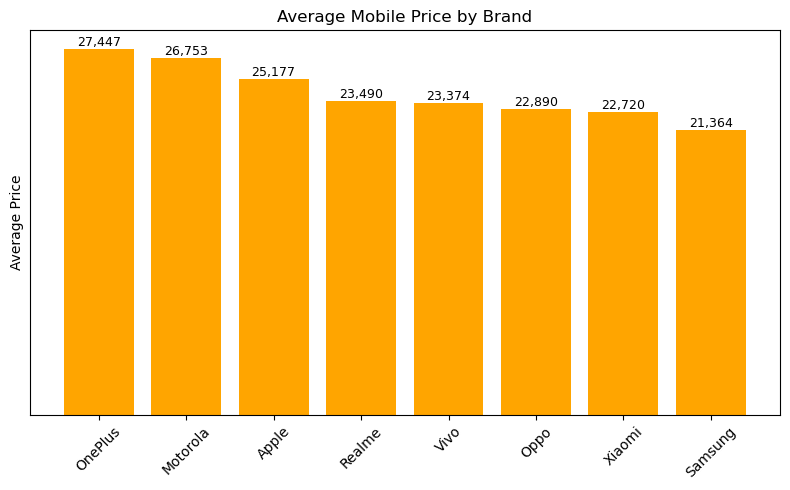

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# MobileModels: Average Price by Brand
brand_price = models.groupby("brand")["price"].mean().reset_index().sort_values("price", ascending=False)
brand_price.to_csv("models_avg_price_by_brand.csv", index=False)

plt.figure(figsize=(8,5))
bars = plt.bar(brand_price["brand"], brand_price["price"], color="orange")
plt.title("Average Mobile Price by Brand")
plt.xticks(rotation=45)
plt.ylabel("Average Price")
plt.yticks([])   # Remove axis numbers

# Add text labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

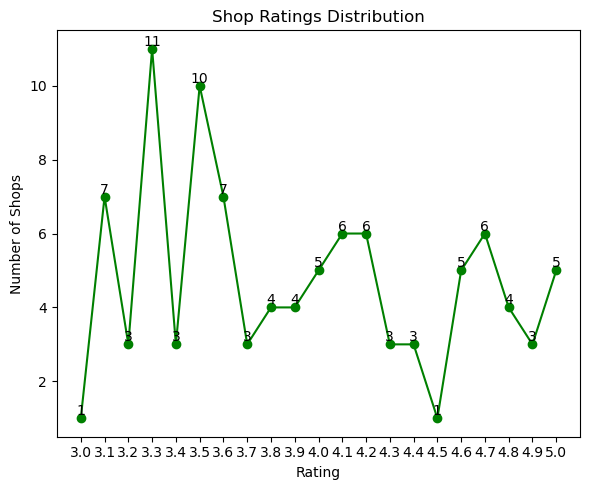

In [11]:
#ShopLocations: Shop Ratings Distribution
# Assuming 'shops' dataframe has a 'rating' column
shop_ratings = shops["rating"].value_counts().reset_index()
shop_ratings.columns = ["rating", "count"]
shop_ratings = shop_ratings.sort_values("rating")

plt.figure(figsize=(6,5))

# Plot line graph
plt.plot(shop_ratings["rating"], shop_ratings["count"], marker='o', color='green', linestyle='-')

plt.title("Shop Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Shops")

# Add data labels on each point
for x, y in zip(shop_ratings["rating"], shop_ratings["count"]):
    plt.text(x, y, str(int(y)), ha="center", va="bottom", fontsize=10)

plt.xticks(shop_ratings["rating"])  # Ensure all ratings appear on x-axis
plt.tight_layout()
plt.show()

C:\Users\TANU\AppData\Local\Temp\ipykernel_22136\1026096501.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.index, y=top_cities.values, palette='viridis')


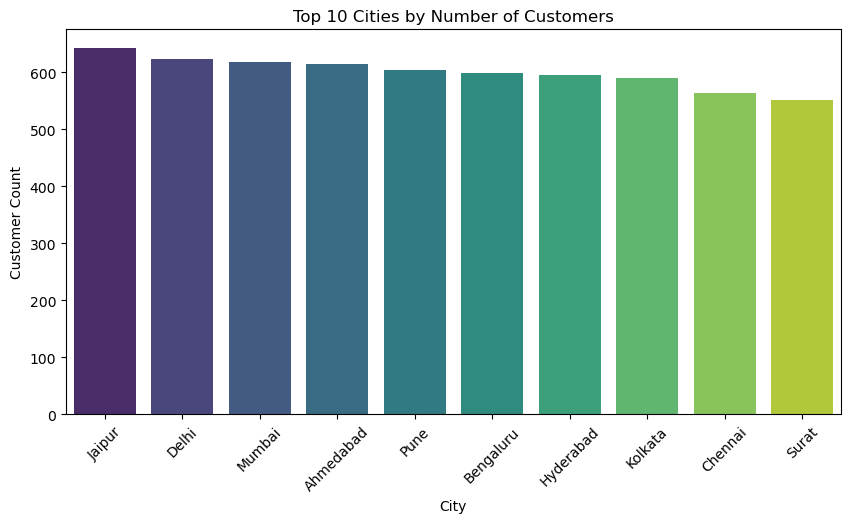

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Customer City Distribution
top_cities = customers['city'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.index, y=top_cities.values, palette='viridis')

plt.title("Top 10 Cities by Number of Customers")
plt.xlabel("City")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)

plt.show()

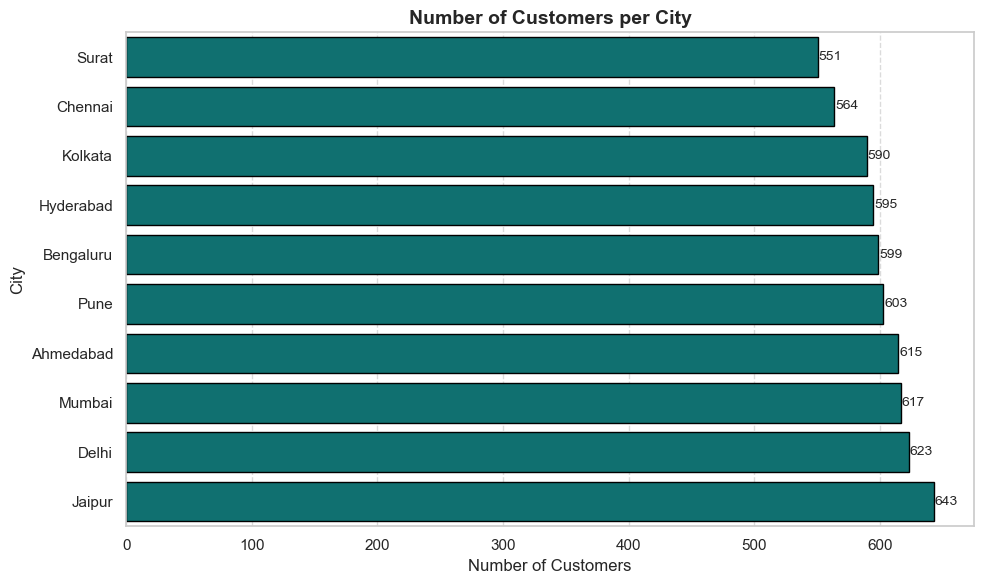

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
customers = pd.read_csv("customers.csv")

# Set Seaborn style for consistency
sns.set(style="whitegrid")

# Count customers per city
city_counts = customers["city"].value_counts().sort_values(ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=city_counts, y=city_counts.index, color="teal", edgecolor="black")

# Titles and labels
plt.title("Number of Customers per City", fontsize=14, fontweight="bold")
plt.xlabel("Number of Customers", fontsize=12)
plt.ylabel("City", fontsize=12)

# Annotate bar values
for index, value in enumerate(city_counts):
    plt.text(value + 0.5, index, str(value), va='center', fontsize=10)

# Grid and layout
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

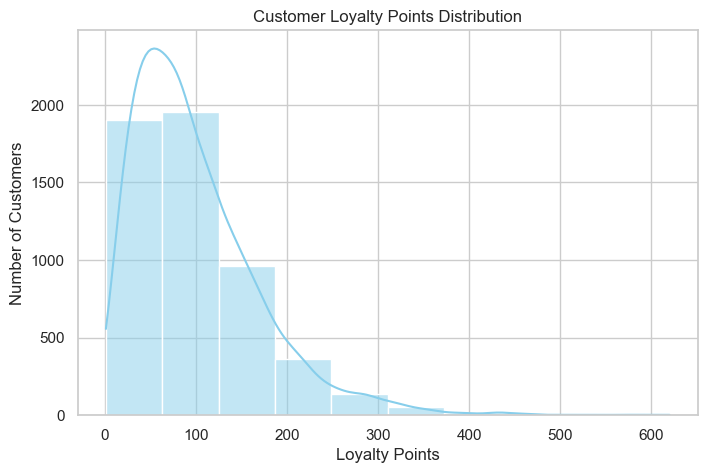

In [14]:
# Loyalty Points Distribution
plt.figure(figsize=(8,5))
sns.histplot(customers['loyalty_points'], bins=10, kde=True, color='skyblue')
plt.title("Customer Loyalty Points Distribution")
plt.xlabel("Loyalty Points"); plt.ylabel("Number of Customers")
plt.show()
# Inference: Shows loyalty engagement intensity among customers.

C:\Users\TANU\AppData\Local\Temp\ipykernel_22136\1994719088.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_purchase.index, y=avg_purchase.values, palette='coolwarm')


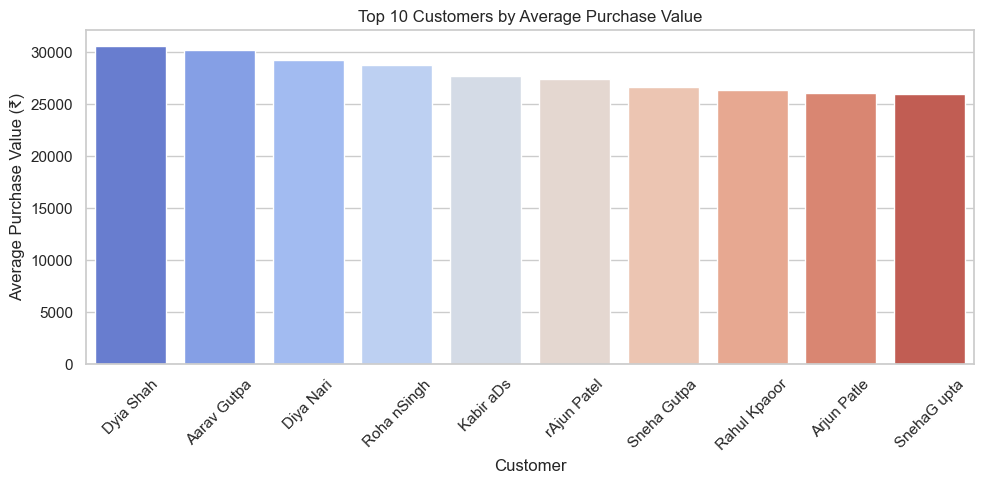

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
customers = pd.read_csv("customers.csv")
sales = pd.read_csv("sales.csv")

# Merge customers and sales on customer_id
merged_df = pd.merge(sales, customers, on='customer_id', how='inner')

# Compute average purchase value per customer
avg_purchase = merged_df.groupby('full_name')['final_price'].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=avg_purchase.index, y=avg_purchase.values, palette='coolwarm')
plt.title("Top 10 Customers by Average Purchase Value")
plt.xlabel("Customer")
plt.ylabel("Average Purchase Value (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()